In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score,silhouette_samples
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA


In [3]:
df = pd.read_csv('Datos/Transformados/df_model_dummies_cluster.csv')
print("Shape inicial:", df.shape)
df.columns

Shape inicial: (52150, 59)


Index(['lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
       'available_units', 'completed_entry_forms_count', 'product_count',
       'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence',
       'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products',
       'returning_inhabitant', 'libere_community', 'asset_type_aparthotel',
       'asset_type_apartment', 'asset_type_hostel',
       'business_segment_Business Group',
       'business_segment_Business Individual',
       'business_segment_Leisure Group', 'business_segment_Leisure Individual',
       'business_segment_MICE Group', 'business_segment_MICE Individual',
       'business_segment_Mid Stay', 'business_segment_Travel Group',
       'business_segment_Travel Individual', 'rate_type_Flexible',
       'rate_type_Mid Stay', 'rate_type_Non Refundable',
       'origin_channel_manager', 'origin_direct_channel', 'origin_email',
       'origin_in_person', 'origin_telephone', 'provincia_ARABA/ALAVA',
     

Definir columnas para escalar

In [4]:
cols_num_cluster = [
    'lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
    'available_units', 'completed_entry_forms_count', 'product_count',
    'reservation_net_value', 'total_adr', 'espera_dias',
    'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia'
]

cols_bin_cluster = [
    'bought_products', 'returning_inhabitant', 'libere_community'
]

# Nos quedamos solo con las que EXISTAN en el df
cols_scale = [c for c in (cols_num_cluster + cols_bin_cluster) if c in df.columns]

df_clustering = df.copy()

print("Shape clustering (incluye dummies):", df_clustering.shape)
print("Nº columnas a escalar:", len(cols_scale))
print("Columnas a escalar:", cols_scale)

Shape clustering (incluye dummies): (52150, 59)
Nº columnas a escalar: 18
Columnas a escalar: ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'product_count', 'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products', 'returning_inhabitant', 'libere_community']


MinMaxScaler a numericas

In [5]:
scaler = MinMaxScaler()

df_scaled = df_clustering.copy()
df_scaled[cols_scale] = scaler.fit_transform(df_scaled[cols_scale])

print("Shape tras MinMaxScaler:", df_scaled.shape)

Shape tras MinMaxScaler: (52150, 59)


PCA

In [6]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print("Dimensiones originales:", df_scaled.shape[1])
print("Dimensiones tras PCA:", X_pca.shape[1])
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())


Dimensiones originales: 59
Dimensiones tras PCA: 28
Varianza explicada total: 0.9547884840620783


Dataframe final con componentes principales

In [7]:
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
print(X_pca_df.shape)
X_pca_df.head()

(52150, 28)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
0,-0.898277,-0.737884,-0.674842,0.076448,-0.645328,0.439286,0.311900,0.458612,-0.056230,-0.043267,...,-0.337370,-0.318295,-0.241278,0.167770,-0.408852,-0.397529,-0.159718,0.016002,0.418082,0.096484
1,-0.818787,-0.661113,-0.760854,-0.119344,-0.583836,0.247107,0.645214,1.058432,0.457305,-0.006249,...,-0.268705,-0.350659,-0.209846,0.176344,-0.427195,-0.373838,-0.176975,-0.008288,0.393733,0.131135
2,-0.772924,-0.245324,0.580101,0.136866,0.556561,0.952366,0.447726,0.033209,-0.054261,0.184209,...,-0.381910,-0.478774,-0.014588,0.124429,-0.309717,-0.337959,-0.066441,0.918931,0.607189,-0.009841
3,-0.797271,-0.270416,0.595587,0.121359,0.509547,0.928949,0.429984,0.072268,-0.100600,0.143500,...,-0.318609,-0.478136,-0.036970,0.129658,-0.322475,-0.366150,-0.107534,0.608916,0.555571,0.019694
4,-0.825007,-0.783852,-0.626020,0.301565,-0.571096,0.599985,0.198547,0.108923,-0.146662,0.074922,...,-0.185234,-0.492854,-0.036965,0.152096,-0.347623,-0.405101,-0.171603,-0.040477,0.518558,0.039972


### Clustering KMEANS (k 2..10)


KMeans silhouette: {2: 0.13474533907527694, 3: 0.20852807608189383, 4: 0.1779651107123008, 5: 0.17545040591793523, 6: 0.16064097530169064, 7: 0.1393463942084177, 8: 0.14674809798062863, 9: 0.15634706273274795, 10: 0.17347816928220638}
Best KMeans k: 3 sil: 0.20852807608189383


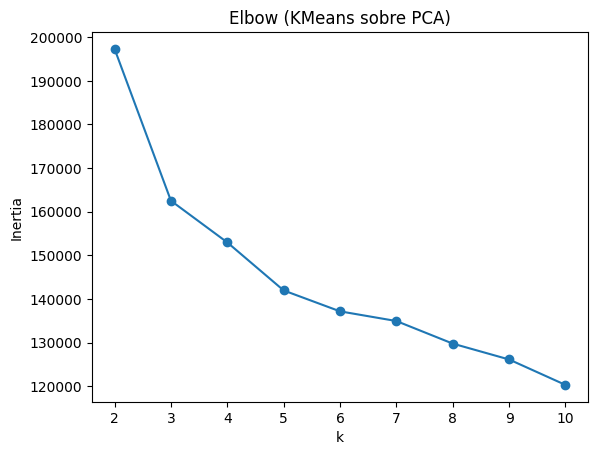

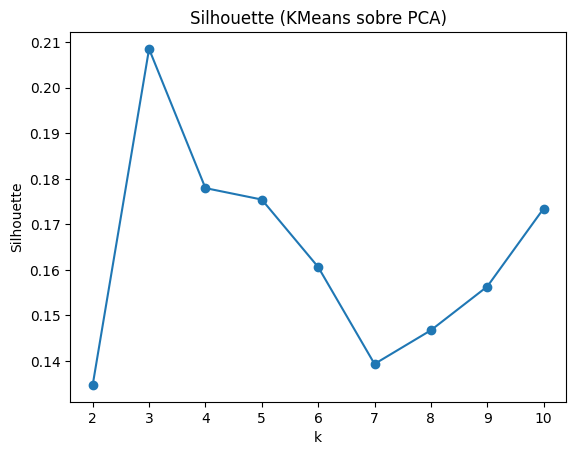

In [7]:
X = X_pca_df.values

Ks = range(2, 11)
kmeans_sil = {}
kmeans_inertia = {}

SAMPLE_SIZE = 26000

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    kmeans_inertia[k] = km.inertia_
    kmeans_sil[k] = silhouette_score(X, labels, sample_size=min(SAMPLE_SIZE, X.shape[0]), random_state=42)

print("KMeans silhouette:", kmeans_sil)
best_k = max(kmeans_sil, key=kmeans_sil.get)
print("Best KMeans k:", best_k, "sil:", kmeans_sil[best_k])

plt.figure()
plt.plot(list(kmeans_inertia.keys()), list(kmeans_inertia.values()), marker="o")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow (KMeans sobre PCA)")
plt.show()

plt.figure()
plt.plot(list(kmeans_sil.keys()), list(kmeans_sil.values()), marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette (KMeans sobre PCA)")
plt.show()

### Clustering JERÁRQUICO (Agglomerative) (k 2..10)


Agglomerative silhouette (sample): {2: 0.15368425706294378, 3: 0.208773799276555, 4: 0.16548364209276442, 5: 0.1455790054725293, 6: 0.14854485552102178, 7: 0.14890699264550578, 8: 0.13797068530494677, 9: 0.1308418328395197, 10: 0.14216916836554389}
Best Agglomerative k: 3 sil: 0.208773799276555


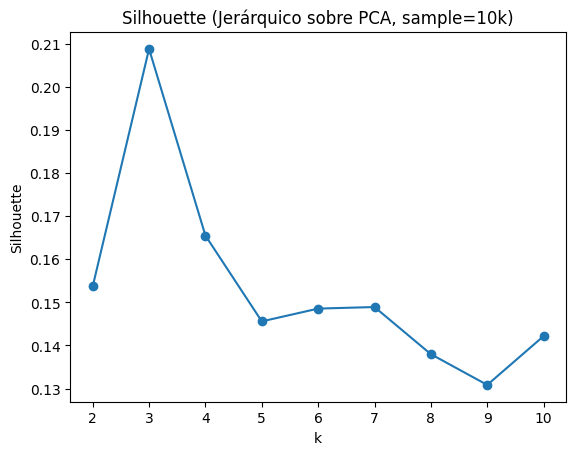

In [8]:
# Usamos muestra para evitar tiempos excesivos
rng = np.random.RandomState(42)
SAMPLE_HAC = 26000

idx = rng.choice(X.shape[0], size=min(SAMPLE_HAC, X.shape[0]), replace=False) # ward suele ir bien con euclídea
X_hac = X[idx]

agg_sil = {}
for k in Ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_hac)
    agg_sil[k] = silhouette_score(
        X_hac, labels,
        sample_size=min(5000, X_hac.shape[0]),
        random_state=42
    )

print("Agglomerative silhouette (sample):", agg_sil)
best_k_agg = max(agg_sil, key=agg_sil.get)
print("Best Agglomerative k:", best_k_agg, "sil:", agg_sil[best_k_agg])

plt.figure()
plt.plot(list(agg_sil.keys()), list(agg_sil.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette (Jerárquico sobre PCA, sample=10k)")
plt.show()


### Clustering DBSCAN (probamos varios eps/min_samples)


In [9]:
eps_list = [0.3, 0.5, 0.7, 0.9, 1.1]
min_samples_list = [5, 10, 20]

dbscan_results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        # clusters válidos (excluye ruido -1)
        unique_labels = set(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        sil = None
        if n_clusters >= 2:
            # silhouette solo sobre puntos NO ruido
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask], sample_size=min(SAMPLE_SIZE, mask.sum()), random_state=42)

        dbscan_results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

# Ordenar: primero los que tienen silhouette (no None), y por silhouette desc
dbscan_results_sorted = sorted(
    dbscan_results,
    key=lambda d: (-1 if d["silhouette"] is None else d["silhouette"]),
    reverse=True
)

print("\nTop DBSCAN configs (mejores silhouette):")
for r in dbscan_results_sorted[:10]:
    print(r)


Top DBSCAN configs (mejores silhouette):
{'eps': 0.3, 'min_samples': 20, 'n_clusters': 362, 'n_noise': np.int64(27344), 'silhouette': 0.6716842522441243}
{'eps': 0.3, 'min_samples': 10, 'n_clusters': 733, 'n_noise': np.int64(20715), 'silhouette': 0.6611586227332418}
{'eps': 0.3, 'min_samples': 5, 'n_clusters': 1618, 'n_noise': np.int64(13450), 'silhouette': 0.6387801421745035}
{'eps': 0.5, 'min_samples': 20, 'n_clusters': 466, 'n_noise': np.int64(21045), 'silhouette': 0.6272868094315087}
{'eps': 0.5, 'min_samples': 10, 'n_clusters': 925, 'n_noise': np.int64(14041), 'silhouette': 0.6179625740465547}
{'eps': 0.5, 'min_samples': 5, 'n_clusters': 1754, 'n_noise': np.int64(7886), 'silhouette': 0.6130738513331532}
{'eps': 0.7, 'min_samples': 20, 'n_clusters': 516, 'n_noise': np.int64(19003), 'silhouette': 0.6073615096427747}
{'eps': 0.7, 'min_samples': 5, 'n_clusters': 1832, 'n_noise': np.int64(6529), 'silhouette': 0.6027909082350108}
{'eps': 0.7, 'min_samples': 10, 'n_clusters': 1006, 'n_n

KMeans y Jerárquico coinciden en k=3 con el mejor silhouette (~0.209). 

Se selecciona KMeans por su menor coste computacional y facilidad de interpretación. 

DBSCAN genera cientos/miles de clusters y una proporción alta de ruido, por lo que se descarta para segmentación operativa

Generando gráficos con el dataset completo (52150 registros)...
Para k=2, el Silhouette Score promedio es: 0.1352


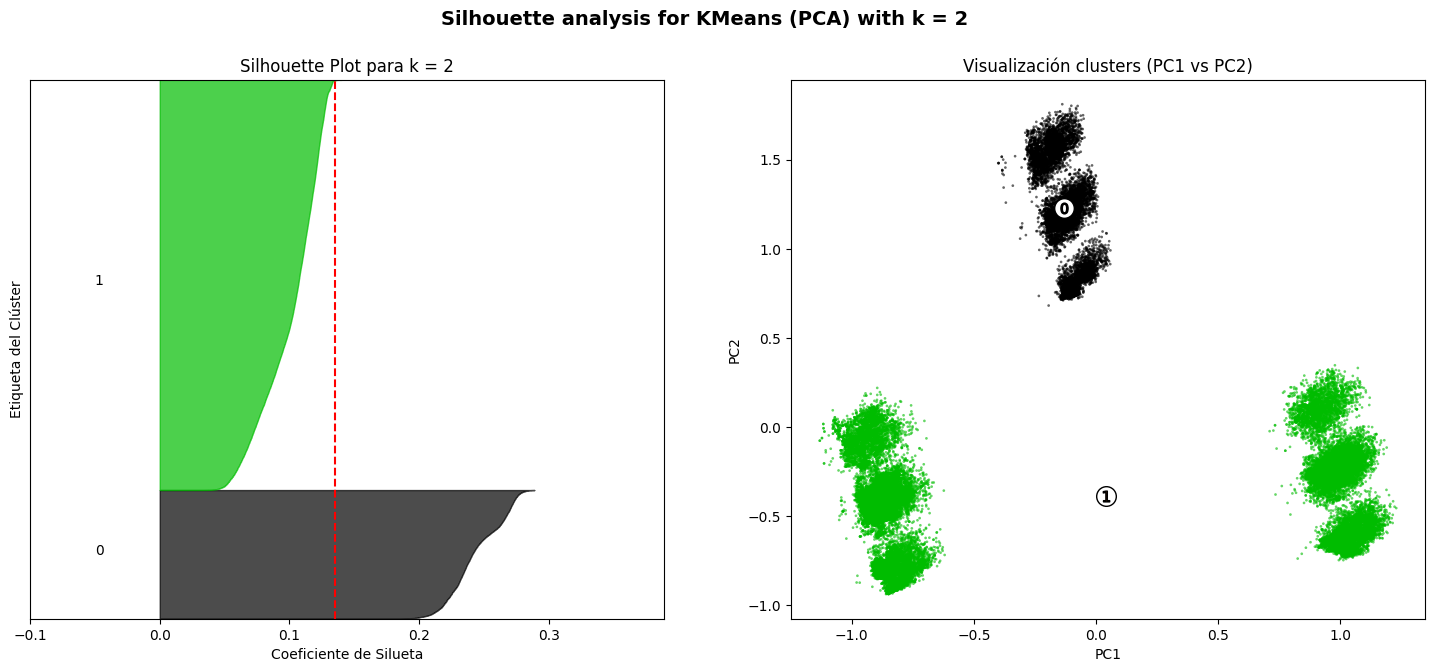

Para k=3, el Silhouette Score promedio es: 0.2088


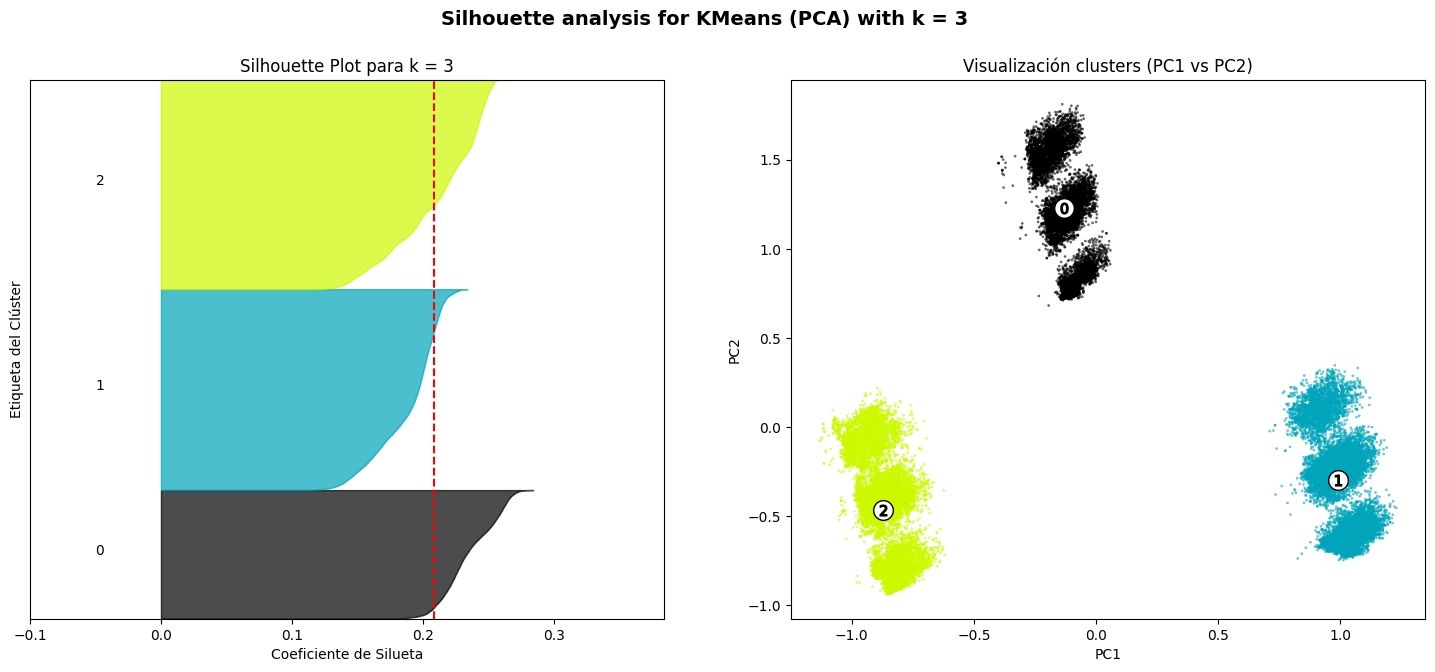

Para k=4, el Silhouette Score promedio es: 0.1784


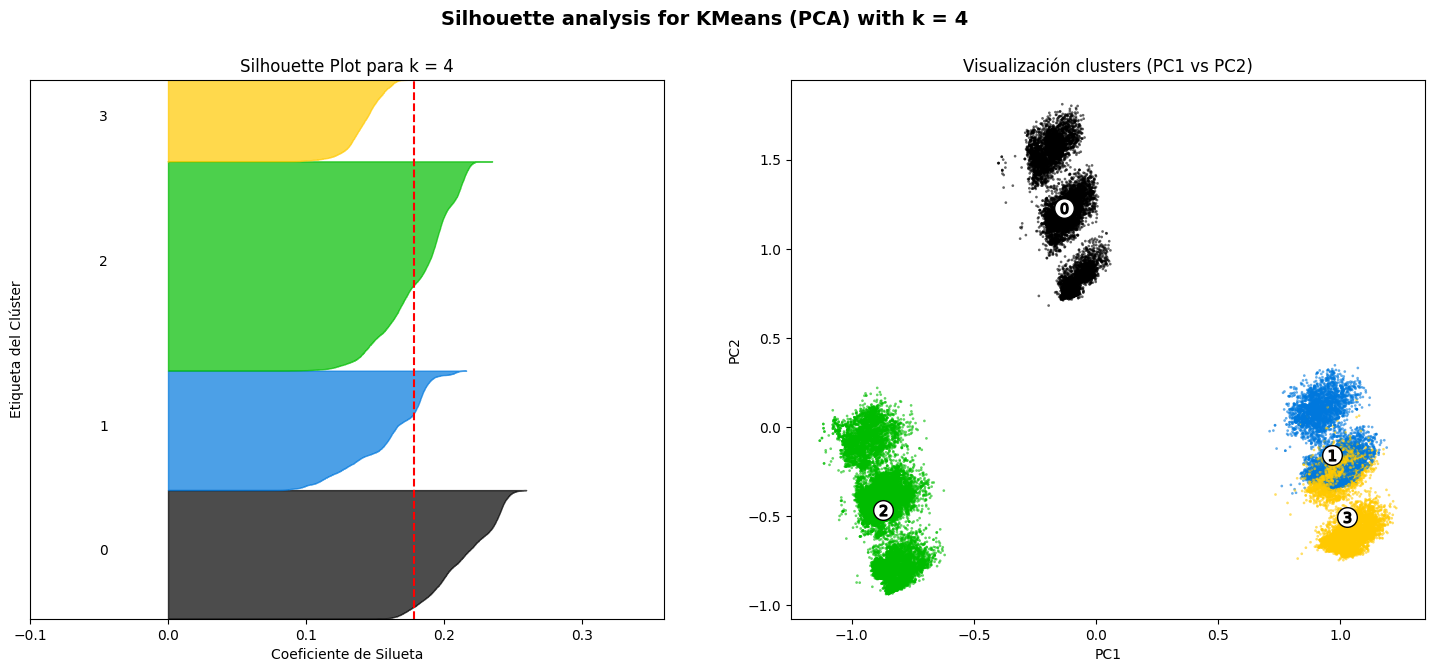

Para k=5, el Silhouette Score promedio es: 0.1756


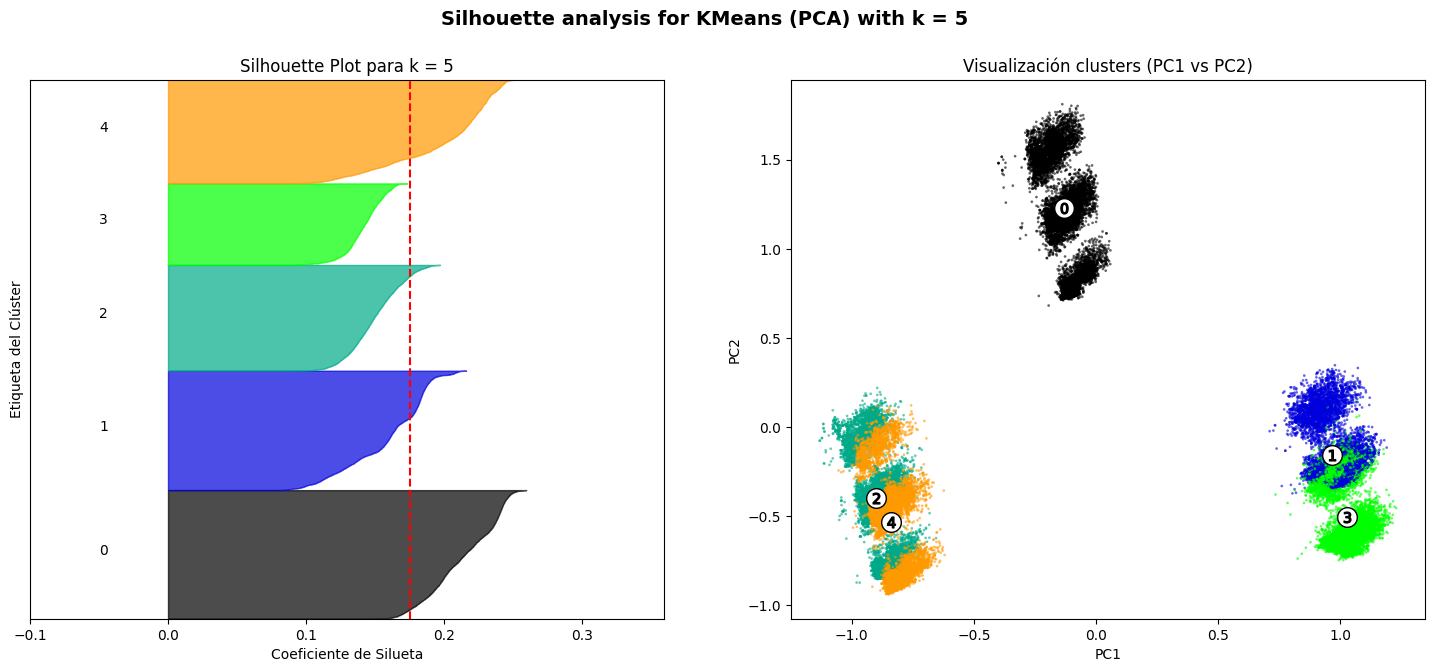

Para k=6, el Silhouette Score promedio es: 0.1610


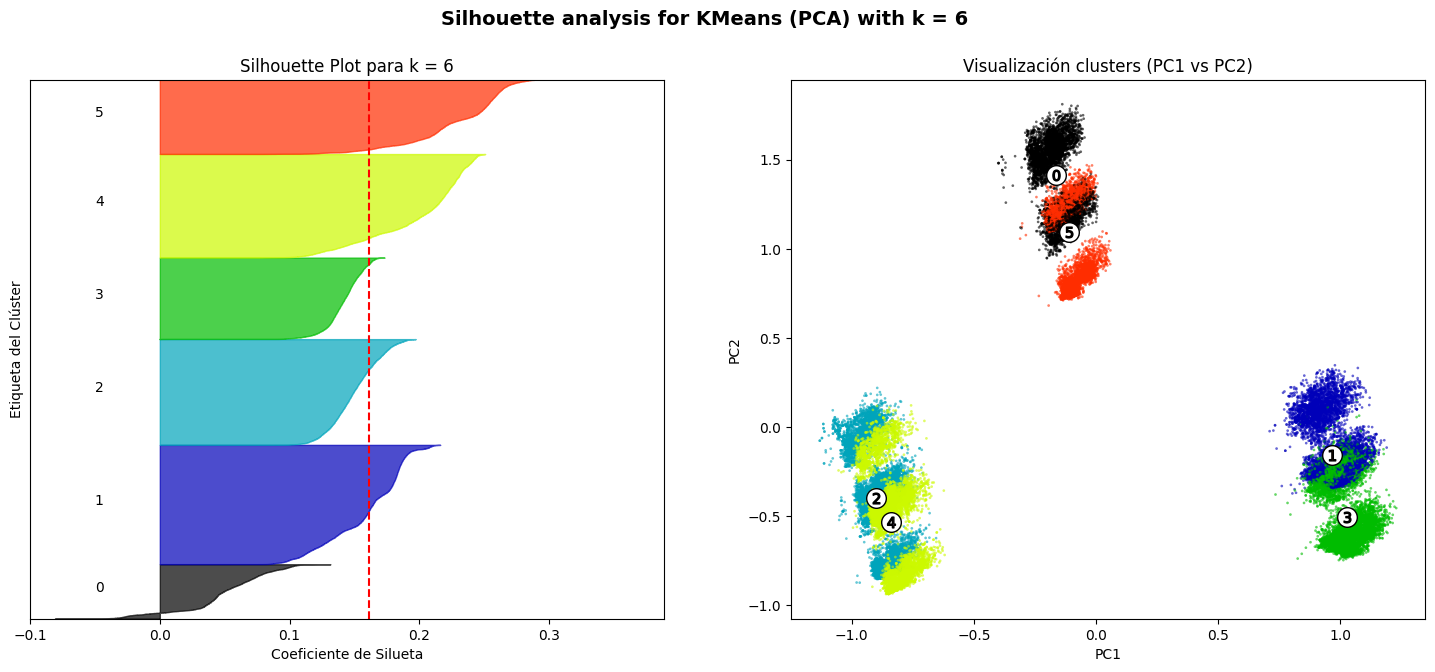

Para k=7, el Silhouette Score promedio es: 0.1395


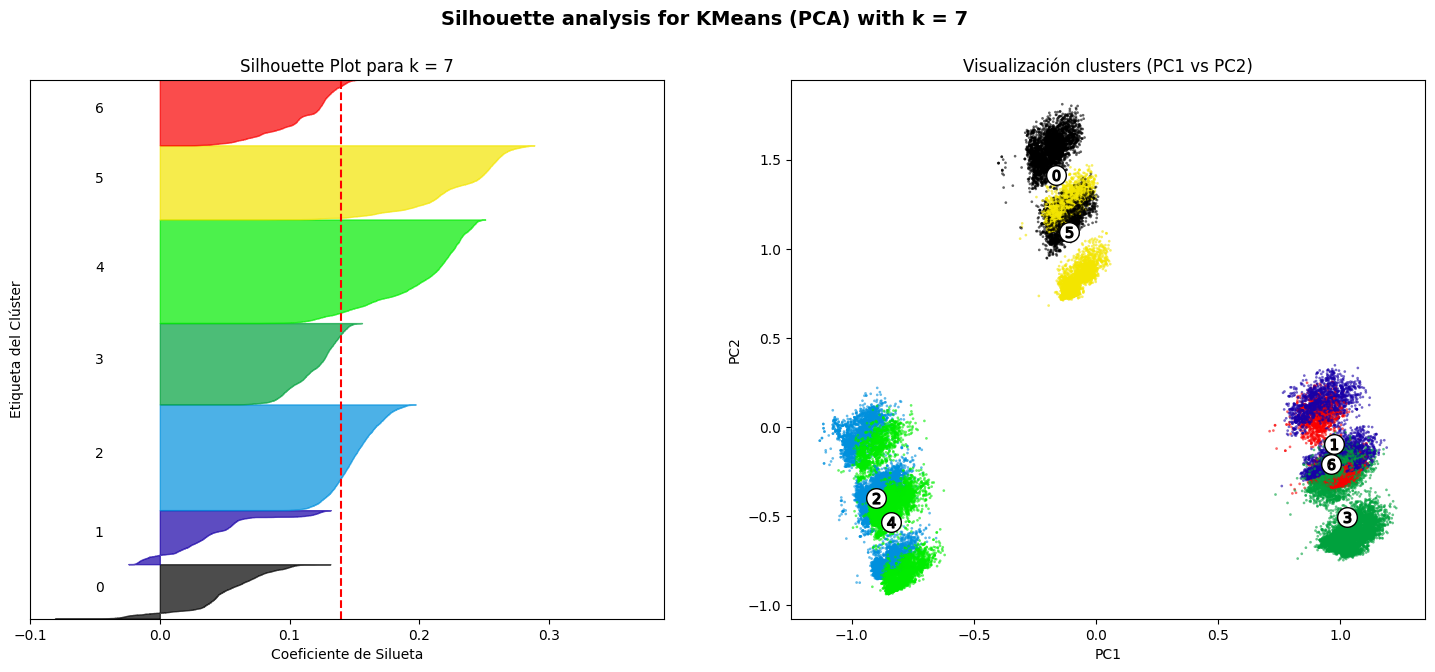

Para k=8, el Silhouette Score promedio es: 0.1471


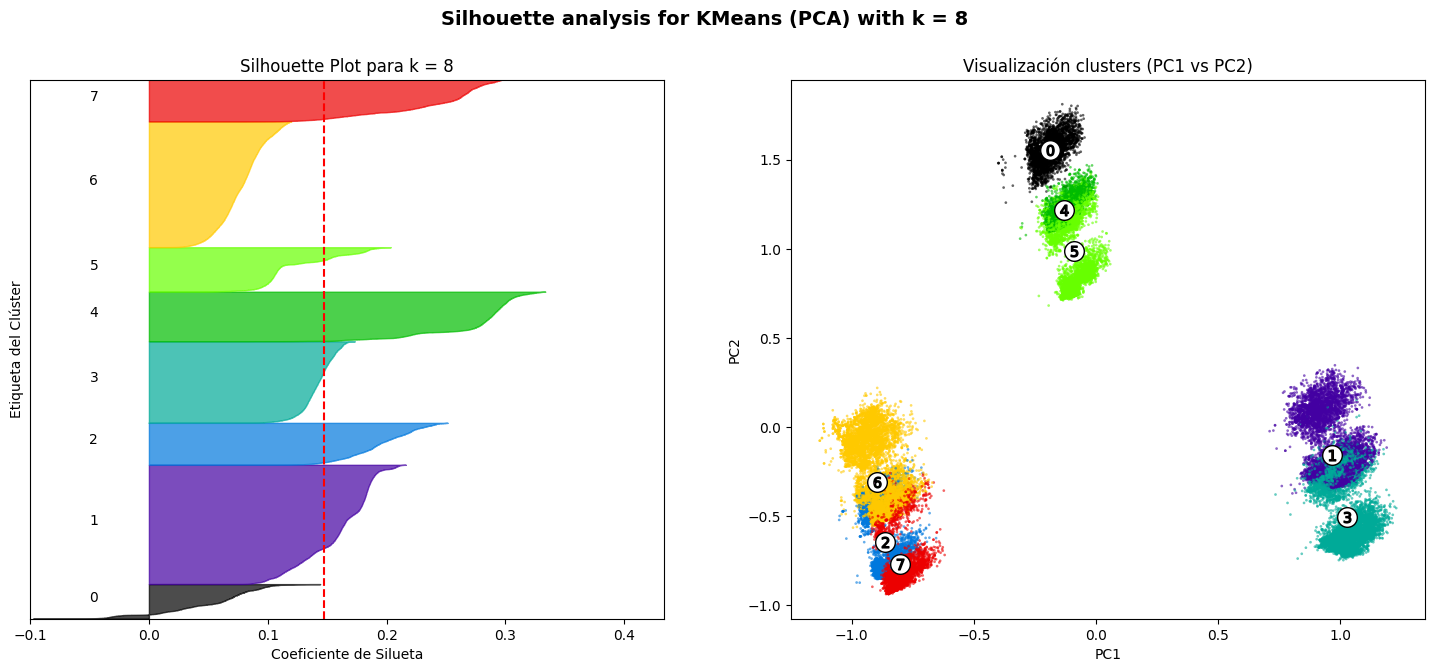

Para k=9, el Silhouette Score promedio es: 0.1562


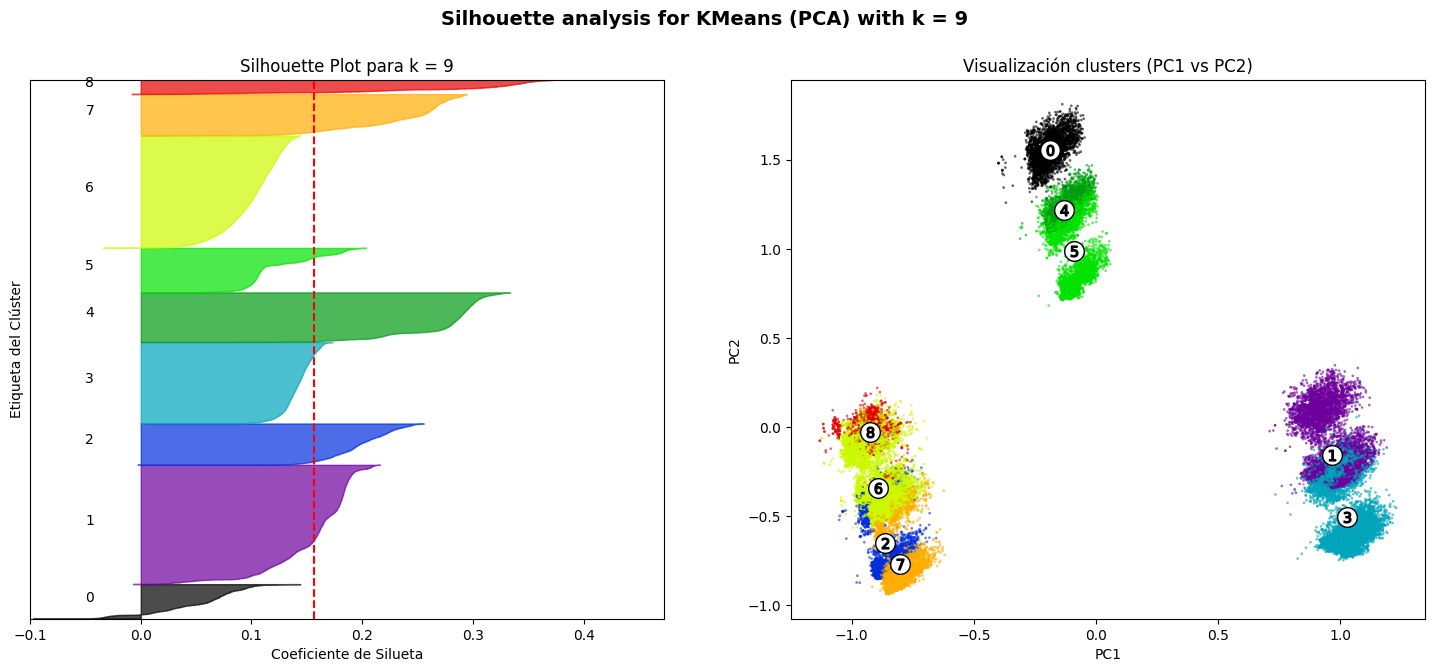

Para k=10, el Silhouette Score promedio es: 0.1737


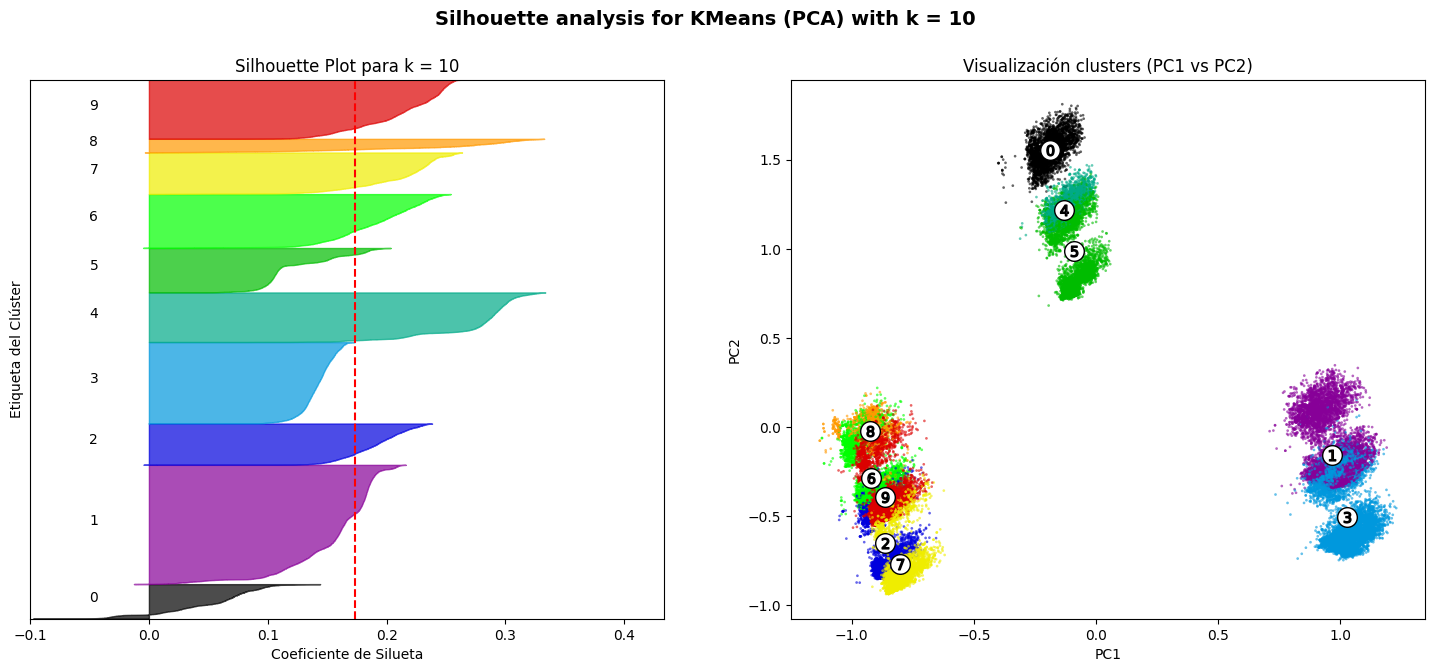

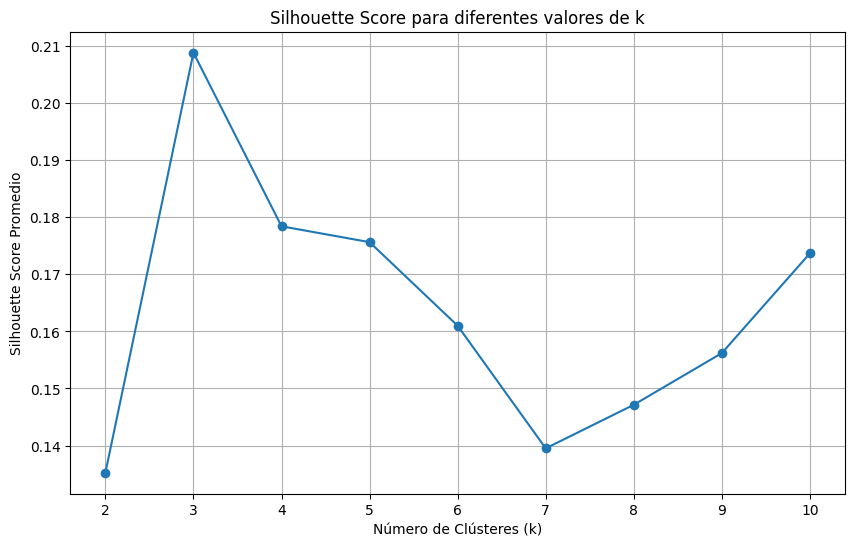

In [ ]:
# Usamos TODOS los datos del PCA
X = X_pca_df.values

# Para el scatter 2D usamos PC1 y PC2
X_2d = X_pca_df[['PC1', 'PC2']].values

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = []

print(f"Generando gráficos con el dataset completo ({len(X)} registros)...")

for n_clusters in range_n_clusters:
    # 1. Crear el modelo
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = clusterer.fit_predict(X)

    # 2. Silhouette medio
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para k={n_clusters}, el Silhouette Score promedio es: {silhouette_avg:.4f}")

    # 3. Silhouette por muestra
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    # 4. Crear figura con DOS gráficos (izq + der)
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # -----------------------
    # GRÁFICO IZQUIERDO
    # -----------------------
    
    # Calcular el valor máximo real de tus siluetas
    max_score = sample_silhouette_values.max()
    
    # Ajustar el límite a ese máximo + un margen de 0.1
    ax1.set_xlim([-0.1, max_score + 0.1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette Plot para k = {n_clusters}")
    ax1.set_xlabel("Coeficiente de Silueta")
    ax1.set_ylabel("Etiqueta del Clúster")
    ax1.set_yticks([])

    # -----------------------
    # GRÁFICO DERECHO (PC1 vs PC2)
    # -----------------------
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    ax2.scatter(
        X_2d[:, 0], X_2d[:, 1],
        marker='.', s=15, lw=0, alpha=0.6,
        c=colors, edgecolor='k'
    )

    # Centros (solo PC1 y PC2)
    centers = clusterer.cluster_centers_[:, :2]
    ax2.scatter(
        centers[:, 0], centers[:, 1],
        marker='o', c='white', s=200, edgecolor='k'
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f'${i}$', s=60, edgecolor='k')

    ax2.set_title("Visualización clusters (PC1 vs PC2)")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.suptitle(
        f"Silhouette analysis for KMeans (PCA) with k = {n_clusters}",
        fontsize=14, fontweight='bold'
    )

    plt.show()

# -----------------------
# GRÁFICO RESUMEN FINAL
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score Promedio')
plt.title('Silhouette Score para diferentes valores de k')
plt.grid(True)
plt.show()

In [16]:
# mejor cluster el k=3
# Para k=3, el Silhouette Score promedio es: 0.2088
# El análisis de Silhouette indica que existen 3 segmentos de clientes bien diferenciados.
# Probar k mayores (4, 5, 6...) tiende a forzar divisiones adicionales con menor calidad global (menor Silhouette),
# por lo que k=3 es la decisión más robusta tanto técnica como para negocio.

In [ ]:
# --- GENERACIÓN DEL ARCHIVO FINAL (MODELO GANADOR K=3) ---

# 1. Entrenar el modelo definitivo con K=3
print("Entrenando modelo final K-Means (K=3)...")
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init="auto")

# Usamos los datos del PCA (X_pca) ya calculados
clusters = kmeans_final.fit_predict(X_pca)

# 2. Recuperar el DataFrame original (con todas las columnas originales)
df_final = pd.read_csv('Datos/Transformados/df_AEMET.csv')

# 3. Añadir la columna cluster
# (IMPORTANTE: esto asume que df_final y X_pca tienen el mismo orden y número de filas)
print("Filas df_final:", len(df_final), "| Filas clusters:", len(clusters))
df_final['cluster'] = clusters

# 4. Guardar para el equipo
output_file = 'Datos/Transformados/df_final_para_regresion.csv'
df_final.to_csv(output_file, index=False)

print(f"¡Listo! Archivo guardado en: {output_file}")
print("Distribución de clientes por cluster:")
print(df_final['cluster'].value_counts().sort_index())


Entrenando modelo final K-Means (K=3)...


C:\Users\Javi\AppData\Local\Temp\ipykernel_27168\2380796709.py:11: DtypeWarning: Columns (48,55,57,61,64,66,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('Datos/Transformados/df_AEMET.csv')


Filas df_final: 52150 | Filas clusters: 52150
¡Listo! Archivo guardado en: Datos/Transformados/df_final_para_regresion.csv
Distribución de clientes por cluster:
cluster
0    12447
1    19442
2    20261
Name: count, dtype: int64


In [18]:
print("Filas df_scaled:", df_scaled.shape[0])
print("Filas df_AEMET:", df_final.shape[0])


Filas df_scaled: 52150
Filas df_AEMET: 52150
